# Transfer Learning for Steel Surface Defect Classification

## 1. Problem Definition

### 1.1 Industrial Problem

Manufacturing companies need to identify surface defects in industrial materials efficiently and consistently. Manual visual inspection can be time-consuming and may be affected by human variability.

In this project, we investigate whether transfer learning can be used to automatically classify different types of steel surface defects from images.

### 1.2 Project Objective

The objective is to develop an image-classification model that can distinguish between six types of steel surface defects using transfer learning.

The project uses a pretrained ResNet50V2 model and adapts it to the steel-defect classification task.

### 1.3 Why Transfer Learning?

Instead of training a convolutional neural network from scratch, we use knowledge learned from a model that was previously trained on a large image dataset.

The pretrained model provides general visual features that can be adapted to the target domain of steel surface defects.

---

## 2. Dataset

### 2.1 NEU Surface Defect Dataset

The project uses the [NEU Surface Defect Dataset](https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database), containing 1,800 grayscale images of steel surfaces across six defect categories, with 300 images per category.

The downloaded dataset provides 1,440 images for training and 360 images for validation.

The grayscale images are converted to three channels during preprocessing so they can be used with the pretrained ResNet50V2 model, which expects RGB input.

### 2.2 Defect Classes

The six defect categories are:

1. Crazing
2. Inclusion
3. Patches
4. Pitted Surface
5. Rolled-in Scale
6. Scratches

### 2.3 Dataset Distribution

The original dataset is balanced across all six classes.

| Split | Images per class | Total images |
|---|---:|---:|
| Training | 240 | 1,440 |
| Validation | 60 | 360 |
| **Total** | **300** | **1,800** |

### 2.4 Example Images

We will visualize representative examples from each defect category before preprocessing.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Reproducibility
SEED = 42

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "NEU-DET"

TRAIN_DIR = DATA_DIR / "train" / "images"
VAL_DIR = DATA_DIR / "validation" / "images"

print("Working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Training data:", TRAIN_DIR)
print("Validation data:", VAL_DIR)

print("\nPaths exist:")
print("Project root:", PROJECT_ROOT.exists())
print("Training data:", TRAIN_DIR.exists())
print("Validation data:", VAL_DIR.exists())

Working directory: c:\Users\Victo\Desktop\Desktop\AI Developer\dev\ai-kurs-remote\09_TransferLearning\notebooks
Project root: c:\Users\Victo\Desktop\Desktop\AI Developer\dev\ai-kurs-remote\09_TransferLearning
Training data: c:\Users\Victo\Desktop\Desktop\AI Developer\dev\ai-kurs-remote\09_TransferLearning\data\raw\NEU-DET\train\images
Validation data: c:\Users\Victo\Desktop\Desktop\AI Developer\dev\ai-kurs-remote\09_TransferLearning\data\raw\NEU-DET\validation\images

Paths exist:
Project root: True
Training data: True
Validation data: True


In [2]:
CLASS_NAMES = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches",
]

print("Classes:")
for i, class_name in enumerate(CLASS_NAMES):
    print(f"{i}: {class_name}")

Classes:
0: crazing
1: inclusion
2: patches
3: pitted_surface
4: rolled-in_scale
5: scratches


In [3]:
def count_images(directory, class_names):
    counts = {}

    for class_name in class_names:
        class_dir = directory / class_name
        counts[class_name] = len(list(class_dir.glob("*")))

    return counts


train_counts = count_images(TRAIN_DIR, CLASS_NAMES)
val_counts = count_images(VAL_DIR, CLASS_NAMES)

print("Training:")
for class_name, count in train_counts.items():
    print(f"  {class_name}: {count}")

print("\nValidation:")
for class_name, count in val_counts.items():
    print(f"  {class_name}: {count}")

Training:
  crazing: 240
  inclusion: 240
  patches: 240
  pitted_surface: 240
  rolled-in_scale: 240
  scratches: 240

Validation:
  crazing: 60
  inclusion: 60
  patches: 60
  pitted_surface: 60
  rolled-in_scale: 60
  scratches: 60


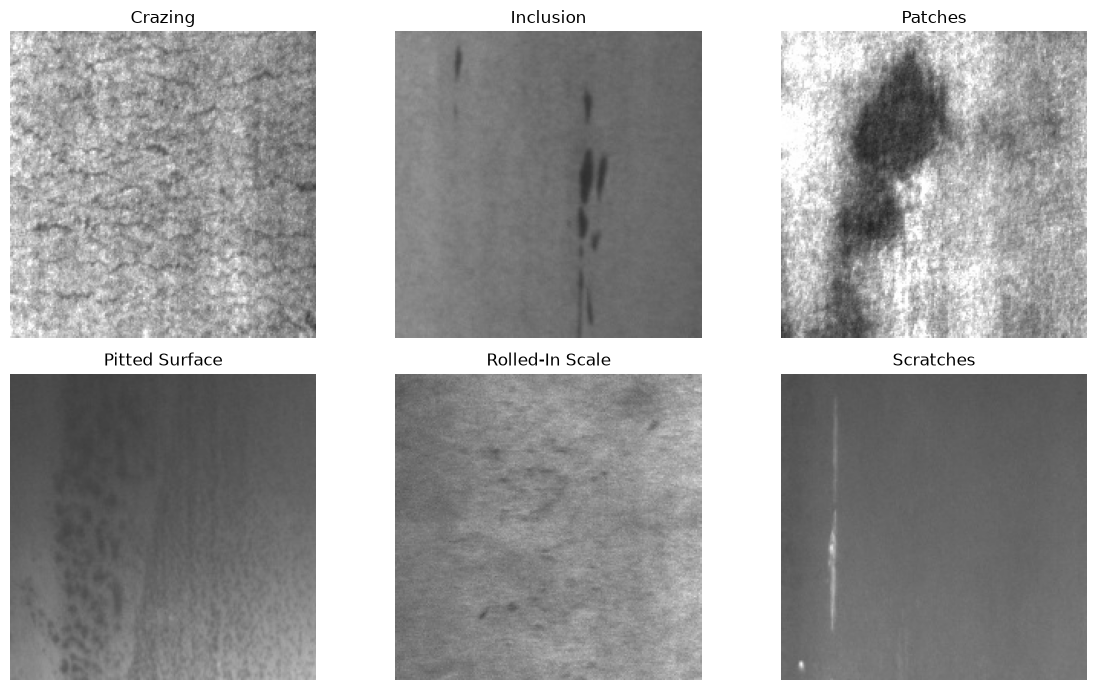

In [4]:
# Select one example from each class
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax, class_name in zip(axes.flat, CLASS_NAMES):
    class_dir = TRAIN_DIR / class_name
    image_path = next(class_dir.glob("*"))

    image = Image.open(image_path)

    ax.imshow(image, cmap="gray")
    ax.set_title(class_name.replace("_", " ").title())
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
sample_path = next((TRAIN_DIR / CLASS_NAMES[0]).glob("*"))
sample_image = Image.open(sample_path)

print("File:", sample_path.name)
print("Format:", sample_image.format)
print("Mode:", sample_image.mode)
print("Size:", sample_image.size)

File: crazing_1.jpg
Format: JPEG
Mode: RGB
Size: (200, 200)


## 3. Data Preparation

### 3.1 Dataset Split

The dataset provides 1,440 training images and 360 additional validation images.

To allow model-development decisions without using the final evaluation data, the 1,440 training images are divided into a training set and a development validation set.

A stratified 90/10 split is used so that all six defect classes remain equally represented.

- Training: 1,296 images
- Development validation: 144 images
- Final evaluation: 360 images

The original 360-image validation set is kept separate and is used only for the final evaluation of the selected model.

A fixed random seed is used to make the split reproducible.


In [6]:
from sklearn.model_selection import train_test_split

# Collect training image paths and labels
image_paths = []
labels = []

for class_name in CLASS_NAMES:
    class_dir = TRAIN_DIR / class_name

    for image_path in class_dir.glob("*.jpg"):
        image_paths.append(image_path)
        labels.append(class_name)

train_df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print(f"Total training images: {len(train_df)}")
print("\nClass distribution:")
print(train_df["label"].value_counts().sort_index())

Total training images: 1440

Class distribution:
label
crazing            240
inclusion          240
patches            240
pitted_surface     240
rolled-in_scale    240
scratches          240
Name: count, dtype: int64


In [7]:
train_paths, dev_paths, train_labels, dev_labels = train_test_split(
    train_df["image_path"],
    train_df["label"],
    test_size=0.10,
    stratify=train_df["label"],
    random_state=SEED
)

train_split = pd.DataFrame({
    "image_path": train_paths,
    "label": train_labels
}).reset_index(drop=True)

dev_split = pd.DataFrame({
    "image_path": dev_paths,
    "label": dev_labels
}).reset_index(drop=True)

print("Training images:", len(train_split))
print("Development validation images:", len(dev_split))

print("\nTraining distribution:")
print(train_split["label"].value_counts().sort_index())

print("\nDevelopment validation distribution:")
print(dev_split["label"].value_counts().sort_index())

Training images: 1296
Development validation images: 144

Training distribution:
label
crazing            216
inclusion          216
patches            216
pitted_surface     216
rolled-in_scale    216
scratches          216
Name: count, dtype: int64

Development validation distribution:
label
crazing            24
inclusion          24
patches            24
pitted_surface     24
rolled-in_scale    24
scratches          24
Name: count, dtype: int64


### 3.2 Image Preprocessing

The original images are 200 × 200 pixels and grayscale.

ResNet50V2 expects RGB images with an input size of 224 × 224 pixels. Therefore, the images are resized to 224 × 224 and converted to three channels during preprocessing.

To avoid changing the aspect ratio of the original images, `tf.image.resize_with_pad()` is used. Since the images are square, no substantial padding is required.


In [8]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


### 3.3 RGB Input Preparation

The original NEU images are grayscale, while the pretrained ResNet50V2 model expects three-channel RGB input.

During preprocessing, the grayscale images are decoded and converted to three channels before being passed to the model. The raw dataset is not modified; preprocessing is performed dynamically when images are loaded.


In [9]:
def load_and_preprocess_image(image_path, label):
    # Convert pathlib.Path to string when called directly.
    # TensorFlow tensors are left unchanged for tf.data.Dataset.
    if isinstance(image_path, Path):
        image_path = str(image_path)

    # Read image
    image = tf.io.read_file(image_path)

    # Decode as RGB
    image = tf.image.decode_jpeg(image, channels=3)

    # Resize to ResNet50V2 input size
    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_SIZE[0],
        target_width=IMG_SIZE[1]
    )

    # ResNet50V2/ImageNet preprocessing
    image = tf.keras.applications.resnet_v2.preprocess_input(image)

    return image, label

In [10]:
sample_path = train_split.loc[0, "image_path"]
sample_label = CLASS_NAMES.index(train_split.loc[0, "label"])

processed_image, processed_label = load_and_preprocess_image(
    sample_path,
    sample_label
)

print("Original:")
print("  Size:", Image.open(sample_path).size)
print("  Mode:", Image.open(sample_path).mode)

print("\nProcessed:")
print("  Shape:", processed_image.shape)
print("  Dtype:", processed_image.dtype)
print("  Label:", processed_label)
print(
    "  Pixel range:",
    float(tf.reduce_min(processed_image)),
    "to",
    float(tf.reduce_max(processed_image))
)

Original:
  Size: (200, 200)
  Mode: RGB

Processed:
  Shape: (224, 224, 3)
  Dtype: <dtype: 'float32'>
  Label: 2
  Pixel range: -1.0 to 1.0


### 3.4 Transfer Learning Setup

We use ResNet50V2 pretrained on ImageNet as the base model.

The pretrained weights are transferred to our steel-defect classification task. The original classification layer is replaced with a new layer for our six defect classes.

Initially, the pretrained layers are frozen and only the new classification head is trained. We will then fine-tune selected later layers and compare the results.

### 3.5 TensorFlow Dataset Pipeline

The images are converted into TensorFlow datasets for efficient batch processing during training and evaluation.

In [11]:
def create_dataset(dataframe, shuffle=False):
    paths = dataframe["image_path"].astype(str).values
    labels = np.array([
        CLASS_NAMES.index(label)
        for label in dataframe["label"]
    ])

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [12]:
train_dataset = create_dataset(train_split, shuffle=True)
dev_dataset = create_dataset(dev_split, shuffle=False)

In [13]:
final_eval_df = pd.DataFrame({
    "image_path": [
        path
        for class_name in CLASS_NAMES
        for path in (VAL_DIR / class_name).glob("*.jpg")
    ]
})

final_eval_df["label"] = final_eval_df["image_path"].apply(
    lambda path: path.parent.name
)

final_eval_dataset = create_dataset(
    final_eval_df,
    shuffle=False
)

In [14]:
print("Training images:", len(train_split))
print("Development validation images:", len(dev_split))
print("Final evaluation images:", len(final_eval_df))

print("\nBatches:")
print(
    "Training:",
    tf.data.experimental.cardinality(train_dataset).numpy()
)
print(
    "Development validation:",
    tf.data.experimental.cardinality(dev_dataset).numpy()
)
print(
    "Final evaluation:",
    tf.data.experimental.cardinality(final_eval_dataset).numpy()
)

Training images: 1296
Development validation images: 144
Final evaluation images: 360

Batches:
Training: 41
Development validation: 5
Final evaluation: 12


## 4. Baseline: Pretrained ResNet50V2

### 4.1 ResNet50V2 Architecture

ResNet50V2 is used as the base convolutional neural network. The pretrained classification layer is removed so that the network can be adapted to the six steel-defect classes.


In [15]:
base_model = tf.keras.applications.ResNet50V2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("Base model loaded.")
print("Number of layers:", len(base_model.layers))

Base model loaded.
Number of layers: 190


The base model contains 190 layers and outputs a 7 × 7 × 2048 feature representation for each input image.

### 4.2 ImageNet Pretraining

The base model uses weights pretrained on ImageNet. These pretrained weights provide general visual features that can be reused for the steel-defect classification task.

### 4.3 Frozen Layers

The pretrained ResNet50V2 layers are frozen during the initial training stage. Their weights will not be updated; only the newly added classification head will be trained.

In [16]:
base_model.trainable = False

print("Base model trainable:", base_model.trainable)

Base model trainable: False


### 4.4 Custom Classification Head

The original ImageNet classification layer is replaced with a new classification head for the six steel-defect classes.

Global Average Pooling reduces the feature maps before the final six-class softmax layer.

In [17]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(
        len(CLASS_NAMES),
        activation="softmax"
    )
])

In [18]:
print("Model layers:")
for layer in model.layers:
    print(f"- {layer.name}: {layer.output.shape}")

print("\nTotal parameters:", model.count_params())
print("Trainable parameters:", sum(
    np.prod(v.shape) for v in model.trainable_variables
))
print("Non-trainable parameters:", sum(
    np.prod(v.shape) for v in model.non_trainable_variables
))

Model layers:
- resnet50v2: (None, 7, 7, 2048)
- global_average_pooling2d: (None, 2048)
- dense: (None, 6)

Total parameters: 23577094
Trainable parameters: 12294
Non-trainable parameters: 23564800


### 4.5 Model Compilation

The model is compiled using the Adam optimizer, sparse categorical cross-entropy loss, and accuracy as the training metric.

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 5. Training

### 5.1 Model Checkpointing

The trained model is saved to disk so that it does not need to be retrained every time the notebook is run.

If a previously trained model exists, it is loaded instead of training a new model.


In [20]:
MODEL_PATH = PROJECT_ROOT / "models" / "resnet50v2_frozen.keras"

print("Model path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

Model path: c:\Users\Victo\Desktop\Desktop\AI Developer\dev\ai-kurs-remote\09_TransferLearning\models\resnet50v2_frozen.keras
Model exists: True


In [21]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

### 5.2 Stage 1: Frozen Base Training

The first training stage uses the pretrained ResNet50V2 as a frozen feature extractor. Only the new six-class classification head is trained on the NEU dataset.

The model is trained for 10 epochs using the training set and development validation set. The best model is saved based on development validation accuracy.

In [22]:
HISTORY_PATH = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "stage1_training_history.csv"
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

if MODEL_PATH.exists():
    print("Loading existing Stage 1 model...")
    model = tf.keras.models.load_model(MODEL_PATH)

    if HISTORY_PATH.exists():
        history_df = pd.read_csv(HISTORY_PATH)
        print("Training history loaded.")
    else:
        raise FileNotFoundError(
            f"Model exists, but training history was not found: "
            f"{HISTORY_PATH}"
        )

else:
    print("Training Stage 1: frozen ResNet50V2...")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_dataset,
        validation_data=dev_dataset,
        epochs=10,
        callbacks=[checkpoint]
    )

    history_df = pd.DataFrame(history.history)

    history_df.to_csv(
        HISTORY_PATH,
        index=False
    )

    print("Training history saved to:", HISTORY_PATH)

Loading existing Stage 1 model...
Training history loaded.


### 5.3 Training Results

The frozen-base model achieved very high accuracy on the development set. Training and validation curves are used to examine the model's learning behaviour.

In [23]:
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.841049,0.689937,0.979167,0.248037
1,0.983796,0.156220,0.979167,0.130267
2,0.992284,0.090787,0.979167,0.094257
3,0.994599,0.063946,0.986111,0.074661
4,0.996142,0.049302,0.993056,0.061345
5,0.996914,0.038932,0.993056,0.052410
6,0.998457,0.032171,0.993056,0.044965
7,0.998457,0.026796,1.000000,0.040472
8,0.998457,0.023045,1.000000,0.036607
9,0.999228,0.019944,1.000000,0.033334


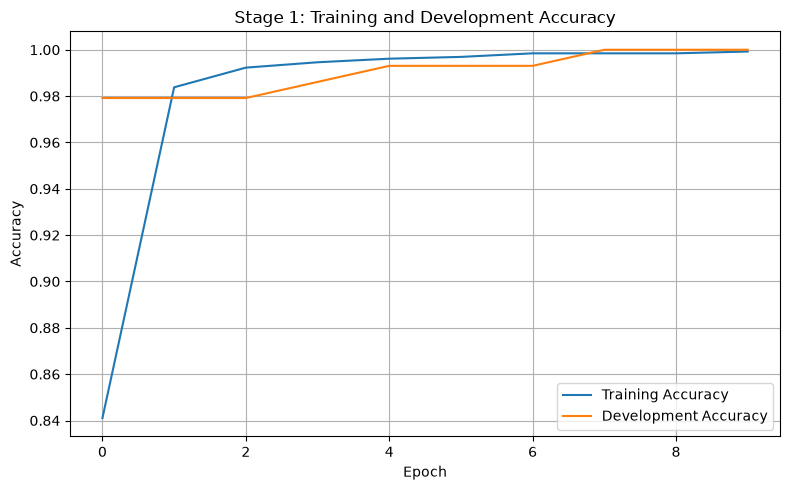

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df["val_accuracy"],
    label="Development Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Stage 1: Training and Development Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "stage1_accuracy.png",
    dpi=150
)

plt.show()

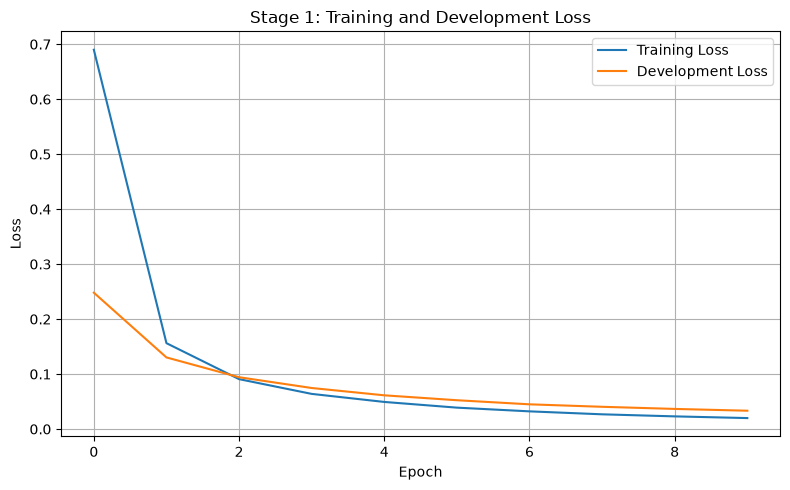

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["loss"],
    label="Training Loss"
)

plt.plot(
    history_df["val_loss"],
    label="Development Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 1: Training and Development Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "stage1_loss.png",
    dpi=150
)

plt.show()

## 6. Stage 1 Evaluation

The best Stage 1 model is evaluated on the final evaluation set of 360 images. These images were kept separate from model training and development validation and are used to estimate performance on unseen data.

In [26]:
# Load the best Stage 1 checkpoint
model = tf.keras.models.load_model(MODEL_PATH)

print("Best Stage 1 model loaded.")

Best Stage 1 model loaded.


In [27]:
stage1_results = model.evaluate(
    final_eval_dataset,
    verbose=1
)

print("\nStage 1 Final Evaluation:")
print(f"Loss: {stage1_results[0]:.4f}")
print(f"Accuracy: {stage1_results[1]:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 650ms/step - accuracy: 0.9722 - loss: 0.1027

Stage 1 Final Evaluation:
Loss: 0.1027
Accuracy: 0.9722


### 6.1 Classification Report

A classification report is used to evaluate precision, recall, and F1-score for each defect class.

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions
y_true = []
y_pred = []

for images, labels in final_eval_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Classification report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)

                 precision    recall  f1-score   support

        crazing     0.9375    1.0000    0.9677        60
      inclusion     1.0000    0.9000    0.9474        60
        patches     0.9836    1.0000    0.9917        60
 pitted_surface     0.9333    0.9333    0.9333        60
rolled-in_scale     1.0000    1.0000    1.0000        60
      scratches     0.9836    1.0000    0.9917        60

       accuracy                         0.9722       360
      macro avg     0.9730    0.9722    0.9720       360
   weighted avg     0.9730    0.9722    0.9720       360



### 6.2 Confusion Matrix

The confusion matrix shows how predictions are distributed across the six steel-surface defect classes. It helps identify which defect types are most frequently confused with one another.

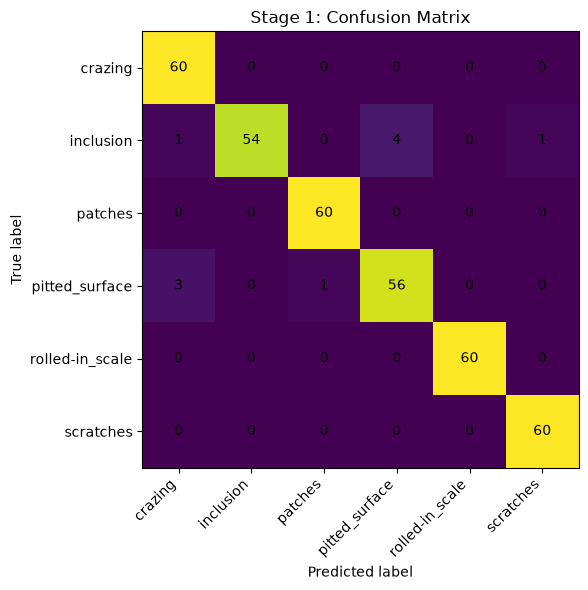

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Stage 1: Confusion Matrix")

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "stage1_confusion_matrix.png",
    dpi=150
)

plt.show()

The confusion matrix shows that most classes are classified correctly. The remaining errors are concentrated mainly in the inclusion and pitted surface classes, with some inclusion samples predicted as pitted surface and some pitted surface samples predicted as crazing.

## 7. Fine-Tuning

The second training stage fine-tunes selected layers of the pretrained ResNet50V2 model on the NEU steel-defect dataset.

Most pretrained layers remain frozen, while later layers are unfrozen so that higher-level visual features can adapt to the target domain.

### 7.1 Load Stage 1 Model

The best Stage 1 model is loaded as the starting point for fine-tuning.

In [30]:
# Load the best Stage 1 model
finetune_model = tf.keras.models.load_model(MODEL_PATH)

print("Stage 1 model loaded for fine-tuning.")

Stage 1 model loaded for fine-tuning.


### 7.2 Selective Unfreezing

The majority of the pretrained ResNet50V2 layers remain frozen. The later layers are unfrozen so that higher-level features can adapt to the steel-defect dataset.

In [31]:
# Keep the ResNet50V2 base frozen initially
base_model = finetune_model.layers[0]

# Unfreeze the later layers of the pretrained base
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

print("Total base model layers:", len(base_model.layers))
print("Trainable base layers:", sum(layer.trainable for layer in base_model.layers))

Total base model layers: 190
Trainable base layers: 30


In [32]:
finetune_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │        12,294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,601,684 (90.03 MB)

 Trainable params: 14,455,814 (55.14 MB)

 Non-trainable params: 9,121,280 (34.79 MB)

 Optimizer params: 24,590 (96.06 KB)

### 7.3 Recompile for Fine-Tuning

The model is recompiled with a lower learning rate to make smaller updates to the pretrained weights during fine-tuning.

In [33]:
finetune_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled.")

Fine-tuning model compiled.


### 7.4 Fine-Tuning Training

The fine-tuned model is trained using the same training and development datasets as Stage 1. The final evaluation set remains untouched until evaluation.

In [34]:
FINETUNED_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "resnet50v2_finetuned.keras"
)

FINETUNE_HISTORY_PATH = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "stage2_finetuning_history.csv"
)

print("Fine-tuned model path:", FINETUNED_MODEL_PATH)
print("Model exists:", FINETUNED_MODEL_PATH.exists())
print("History exists:", FINETUNE_HISTORY_PATH.exists())

Fine-tuned model path: c:\Users\Victo\Desktop\Desktop\AI Developer\dev\ai-kurs-remote\09_TransferLearning\models\resnet50v2_finetuned.keras
Model exists: True
History exists: True


In [35]:
finetune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=FINETUNED_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

The best fine-tuned model is saved based on development validation accuracy so that it can be reused without retraining.

In [36]:
if FINETUNED_MODEL_PATH.exists():
    print("Loading existing fine-tuned model...")

    finetune_model = tf.keras.models.load_model(
        FINETUNED_MODEL_PATH
    )

    if FINETUNE_HISTORY_PATH.exists():
        finetune_history_df = pd.read_csv(
            FINETUNE_HISTORY_PATH
        )
        print("Fine-tuning history loaded.")
    else:
        raise FileNotFoundError(
            f"Model exists, but training history was not found: "
            f"{FINETUNE_HISTORY_PATH}"
        )

else:
    print("Training Stage 2: fine-tuned ResNet50V2...")

    finetune_history = finetune_model.fit(
        train_dataset,
        validation_data=dev_dataset,
        epochs=10,
        callbacks=[finetune_checkpoint]
    )

    finetune_history_df = pd.DataFrame(
        finetune_history.history
    )

    finetune_history_df.to_csv(
        FINETUNE_HISTORY_PATH,
        index=False
    )

    print(
        "Fine-tuning history saved to:",
        FINETUNE_HISTORY_PATH
    )

Loading existing fine-tuned model...
Fine-tuning history loaded.


### 7.5 Fine-Tuning Results

The fine-tuned model reached 100% development accuracy by epoch 2. Development loss continued to decrease throughout training, indicating increasingly confident predictions on the development set.

In [37]:
finetune_history_df

,accuracy,loss,val_accuracy,val_loss
0,0.841049,0.546436,0.993056,0.033228
1,0.980710,0.100270,1.000000,0.025583
2,0.997685,0.039800,1.000000,0.020089
3,1.000000,0.025199,1.000000,0.016081
4,0.998457,0.017647,1.000000,0.014163
5,0.999228,0.014044,1.000000,0.013998
6,0.999228,0.012174,1.000000,0.013613
7,0.998457,0.010821,1.000000,0.013119
8,1.000000,0.009743,1.000000,0.012984
9,1.000000,0.006674,1.000000,0.012444


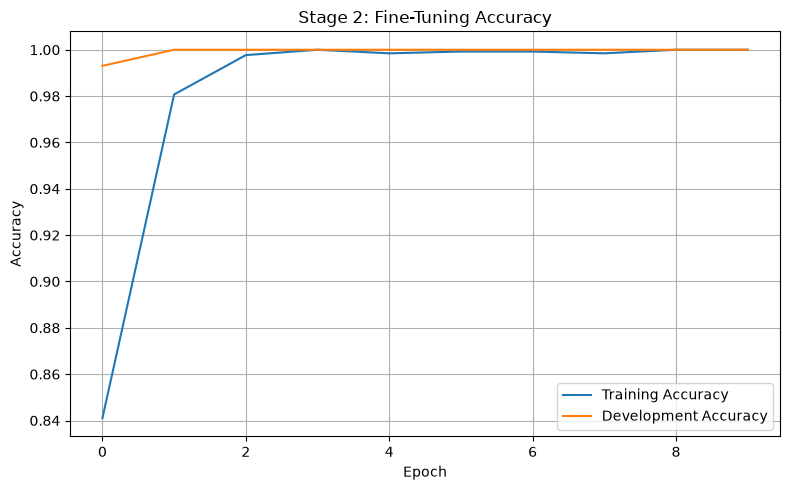

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    finetune_history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    finetune_history_df["val_accuracy"],
    label="Development Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Stage 2: Fine-Tuning Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "stage2_accuracy.png",
    dpi=150
)

plt.show()

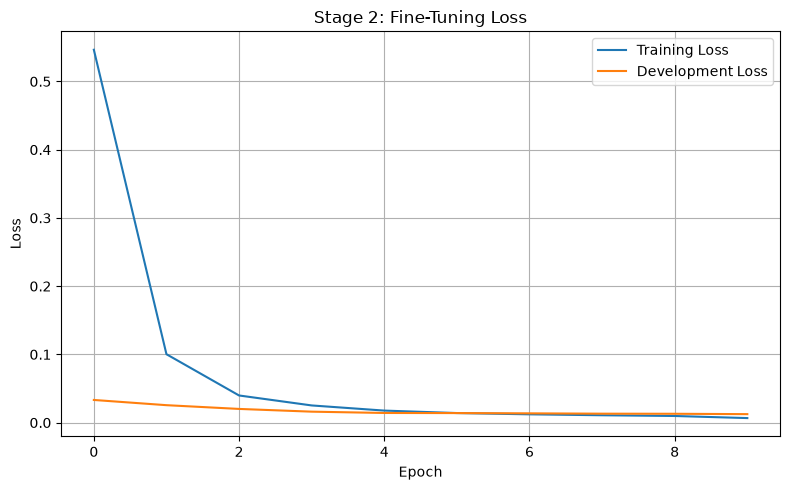

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    finetune_history_df["loss"],
    label="Training Loss"
)

plt.plot(
    finetune_history_df["val_loss"],
    label="Development Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 2: Fine-Tuning Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "stage2_loss.png",
    dpi=150
)

plt.show()

## 8. Stage 2 Evaluation

The best fine-tuned model is evaluated on the same 360-image final evaluation set used to evaluate Stage 1. This allows a direct comparison between the frozen and fine-tuned approaches.

### 8.1 Load Best Fine-Tuned Model

In [40]:
finetune_model = tf.keras.models.load_model(
    FINETUNED_MODEL_PATH
)

print("Best fine-tuned model loaded.")

Best fine-tuned model loaded.


### 8.2 Final Evaluation

In [41]:
stage2_results = finetune_model.evaluate(
    final_eval_dataset,
    verbose=1
)

print("\nStage 2 Final Evaluation:")
print(f"Loss: {stage2_results[0]:.4f}")
print(f"Accuracy: {stage2_results[1]:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 663ms/step - accuracy: 0.9778 - loss: 0.0596

Stage 2 Final Evaluation:
Loss: 0.0596
Accuracy: 0.9778


## 9. Stage 1 vs Stage 2 Comparison

The two transfer-learning approaches are compared using the same final evaluation set.

Stage 1 uses ResNet50V2 as a frozen feature extractor, while Stage 2 fine-tunes the later pretrained layers for the steel-defect classification task.

### 9.1 Final Evaluation Results

In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Stage 1: Frozen",
        "Stage 2: Fine-tuned"
    ],
    "Accuracy": [
        stage1_results[1],
        stage2_results[1]
    ],
    "Loss": [
        stage1_results[0],
        stage2_results[0]
    ]
})

comparison

,Model,Accuracy,Loss
0,Stage 1: Frozen,0.972222,0.102740
1,Stage 2: Fine-tuned,0.977778,0.059559


In [43]:
comparison.to_csv(
    PROJECT_ROOT / "results" / "metrics" / "stage_comparison.csv",
    index=False
)

### 9.2 Accuracy Comparison

Fine-tuning the later pretrained layers improved final evaluation accuracy from 97.22% to 97.78%.

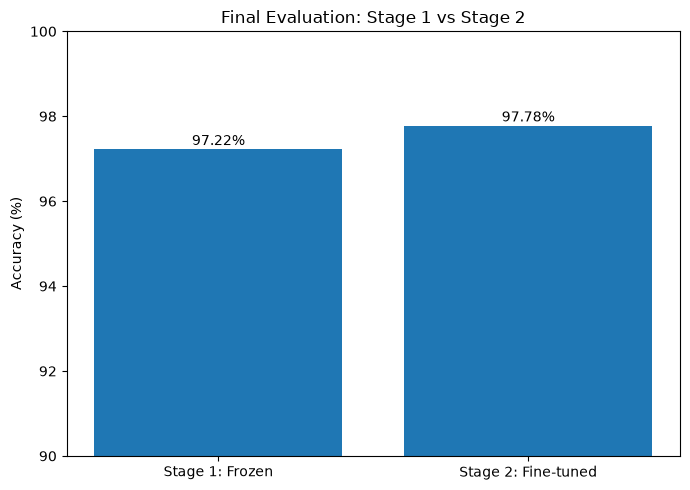

In [44]:
plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")
plt.title("Final Evaluation: Stage 1 vs Stage 2")
plt.ylim(90, 100)

for i, value in enumerate(comparison["Accuracy"] * 100):
    plt.text(
        i,
        value + 0.1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "stage_comparison_accuracy.png",
    dpi=150
)

plt.show()

### 9.3 Classification Comparison

The classification performance of the fine-tuned model is compared with the frozen model for each defect class.

In [45]:
# Generate Stage 2 predictions
y_true_stage2 = []
y_pred_stage2 = []

for images, labels in final_eval_dataset:
    predictions = finetune_model.predict(images, verbose=0)

    y_true_stage2.extend(labels.numpy())
    y_pred_stage2.extend(np.argmax(predictions, axis=1))

print(
    classification_report(
        y_true_stage2,
        y_pred_stage2,
        target_names=CLASS_NAMES,
        digits=4
    )
)

                 precision    recall  f1-score   support

        crazing     0.9524    1.0000    0.9756        60
      inclusion     1.0000    0.9000    0.9474        60
        patches     1.0000    1.0000    1.0000        60
 pitted_surface     0.9206    0.9667    0.9431        60
rolled-in_scale     1.0000    1.0000    1.0000        60
      scratches     1.0000    1.0000    1.0000        60

       accuracy                         0.9778       360
      macro avg     0.9788    0.9778    0.9777       360
   weighted avg     0.9788    0.9778    0.9777       360



### 9.4 Stage 2 Confusion Matrix

The confusion matrix shows the remaining classification errors after fine-tuning.

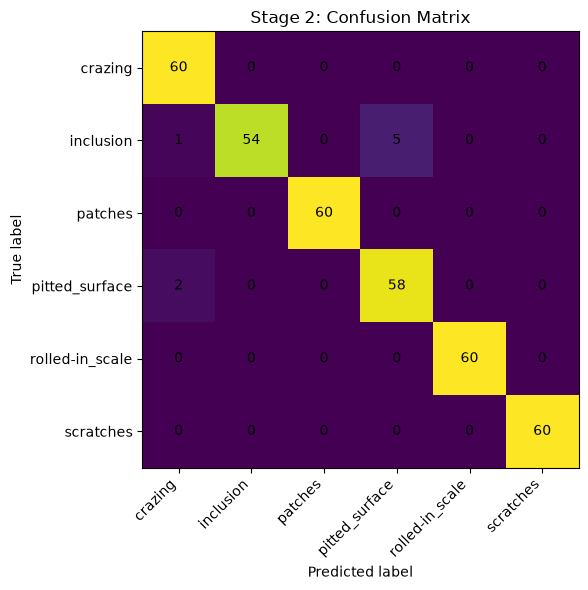

In [46]:
cm_stage2 = confusion_matrix(
    y_true_stage2,
    y_pred_stage2
)

plt.figure(figsize=(8, 6))

plt.imshow(cm_stage2)

plt.xticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Stage 2: Confusion Matrix")

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        plt.text(
            j,
            i,
            cm_stage2[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "stage2_confusion_matrix.png",
    dpi=150
)

plt.show()

### 9.5 Interpretation

Fine-tuning improved final evaluation accuracy from 97.22% to 97.78%.

The improvement was distributed across several classes, with the largest F1-score improvement occurring for pitted surface. Patches and scratches reached perfect F1-scores after fine-tuning.

Inclusion remained the most difficult class in terms of recall, with 90% recall in both stages. This indicates that fine-tuning improved overall performance without eliminating all class-specific classification challenges.

One possible explanation for these remaining errors is that the model receives 2D images of defects occurring on a three-dimensional steel surface. Depth information and the three-dimensional structure of defects may therefore be lost, causing visually similar patterns between classes such as inclusions and pitted surfaces. This may make some defects more difficult to distinguish from a single 2D image.

## 10. Conclusions

This project investigated whether transfer learning could be used to classify six types of steel surface defects using the NEU Surface Defect Dataset.

A ResNet50V2 model pretrained on ImageNet was adapted to the six-class classification task. The initial frozen-base model achieved 97.22% accuracy on the final evaluation set. Fine-tuning the later pretrained layers increased accuracy to 97.78% and reduced evaluation loss from 0.1027 to 0.0596.

The results demonstrate that pretrained visual features can be effectively transferred to a specialized industrial image-classification task. Fine-tuning provided a measurable improvement, although some class-specific errors remained, particularly for inclusion and pitted surface defects.

For an industrial application, further investigation could include additional training data, image augmentation, higher-resolution imaging, and methods that provide more information about the three-dimensional structure of surface defects.